Część 1 — Eksploracja i identyfikacja problemów
Wczytaj plik zamowienia_messy.csv do DataFrame.

In [91]:
import pandas as pd
url = "zamowienia_messy.csv"
df = pd.read_csv(url)

Wykonaj wstępną eksplorację (shape, info, describe, isnull().sum(), value_counts() dla kolumn kategorycznych) i wypisz, jakie problemy z jakością danych widzisz. Wymień co najmniej 5 różnych problemów w komentarzu lub komórce markdown.

In [92]:
print(f"Rozmiar (shape): {df.shape}")
print("\nInfo:")
df.info()
print("\nBraki:")
print(df.isnull().sum())
print("\nvalue_counts")
df["kategoria"].value_counts()

Rozmiar (shape): (520, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB

Braki:
order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64

value_counts


kategoria
Akcesoria      90
akcesoria      90
elektronika    87
Akcesoria      82
Elektronika    80
ELEKTRONIKA    66
Name: count, dtype: int64

Znaleziony problemy:
1. Z zbiorze danych występują braki w kolumnach kategoria, miasto, cena_jednostkowa, data_zamowienia, email.
2. Kolumna kategoria jest stringiem a nie kategorią.
3. Kolumna data_zamowienia jest stringiem a nie datą.
4. Kolumna cena_jednostkowa jest stringiem a nie liczbą.
5. Nazwy kategorii są zdublowane i mogłyby być scalone (np. Akcesoria i akcesoria)

Część 2 — Czyszczenie (6 pkt)

In [93]:
#Standaryzuj kolumny tekstowe klient, produkt, kategoria, miasto — usuń białe znaki, ujednolić wielkość liter 
#(zaproponuj sensowną konwencję, np. title case dla imion i miast, lowercase dla kategorii).
df.columns = df.columns.str.lower()
df["kategoria"] = (
    df["kategoria"]
    .str.strip()           # usuń białe znaki
    .str.lower()           # ujednolić wielkość liter
    .str.replace(r"\s+", " ", regex=True)  # wielokrotne spacje → jedna
)
df["klient"] = (
    df["klient"]
    .str.strip()           # usuń białe znaki
    .str.title()           # ujednolić wielkość liter
    .str.replace(r"\s+", " ", regex=True)  # wielokrotne spacje → jedna
)
df["miasto"] = (
    df["miasto"]
    .str.strip()           # usuń białe znaki
    .str.title()           # ujednolić wielkość liter
    .str.replace(r"\s+", " ", regex=True)  # wielokrotne spacje → jedna
)
df["produkt"] = (
    df["produkt"]
    .str.strip()           # usuń białe znaki
    .str.title()           # ujednolić wielkość liter
    .str.replace(r"\s+", " ", regex=True)  # wielokrotne spacje → jedna
)
df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,13.06.2025,NaN
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00 zł,2025-04-09,marta@gmail.com
2,1003,Anna Kowalska,Mysz,elektronika,Wrocław,1,abc,04.01.2025,JAN@WP.PL
3,1004,Piotr Wiśniewski,Słuchawki,akcesoria,Kraków,1,NaN,05.07.2025,NaN
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1 499.00,2025-02-05,anna@gmail.com


In [94]:
#Zamień kolumnę data_zamowienia na typ datetime — pamiętaj, że są tam dwa różne formaty.
df["data_zamowienia"] = (
    df["data_zamowienia"]
    .str.strip()           # usuń białe znaki
    .str.title()           # ujednolić wielkość liter
    .str.replace(r"\s+", " ", regex=True)  # wielokrotne spacje → jedna
)
df["data_zamowienia"] = pd.to_datetime(df["data_zamowienia"], format='mixed', errors="coerce", dayfirst=True)
df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,NaN
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00 zł,2025-09-04,marta@gmail.com
2,1003,Anna Kowalska,Mysz,elektronika,Wrocław,1,abc,2025-01-04,JAN@WP.PL
3,1004,Piotr Wiśniewski,Słuchawki,akcesoria,Kraków,1,NaN,2025-07-05,NaN
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1 499.00,2025-05-02,anna@gmail.com


In [95]:
#Zamień kolumnę cena_jednostkowa na typ float. Niemożliwe do skonwertowania wartości potraktuj jako braki.
df["cena_jednostkowa"] = pd.to_numeric(
    df["cena_jednostkowa"]
      .astype("string")
      .str.replace(r"[\s\xa0]", "", regex=True)      # usuń spacje i NBSP (separator tys.)
      .str.replace(r"[^\d,\.]", "", regex=True)     # zostaw cyfry, przecinek i kropkę
      .str.replace(",", ".", regex=False),          # przecinek -> kropka
    errors="coerce"
).astype("float64")

df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,NaN
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00,2025-09-04,marta@gmail.com
2,1003,Anna Kowalska,Mysz,elektronika,Wrocław,1,NaN,2025-01-04,JAN@WP.PL
3,1004,Piotr Wiśniewski,Słuchawki,akcesoria,Kraków,1,NaN,2025-07-05,NaN
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1499.00,2025-05-02,anna@gmail.com


In [96]:
#Duplikaty wierszy.
df.info()
print("Duplikaty techniczne (pełny wiersz):", df.duplicated().sum())

key = ["klient", "produkt", "data_zamowienia"]
print(f"Duplikaty biznesowe po {key}:", df.duplicated(subset=key).sum())


<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          520 non-null    int64         
 1   klient            520 non-null    str           
 2   produkt           520 non-null    str           
 3   kategoria         495 non-null    str           
 4   miasto            495 non-null    str           
 5   ilosc             520 non-null    int64         
 6   cena_jednostkowa  397 non-null    float64       
 7   data_zamowienia   495 non-null    datetime64[us]
 8   email             457 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 36.7 KB
Duplikaty techniczne (pełny wiersz): 20
Duplikaty biznesowe po ['klient', 'produkt', 'data_zamowienia']: 30


In [97]:
#wiersze z NaN w cena_jednostkowa lub data_zamowienia — usuń (kluczowe dla analizy),
df = df.dropna(subset=["cena_jednostkowa"]) 
df = df.dropna(subset=["data_zamowienia"])
#braki w miasto i kategoria — wypełnij wartością "unknown"
df["miasto"] = df["miasto"].fillna("unknown") 
df["kategoria"] = df["kategoria"].fillna("unknown") 
#braki w email — wypełnij "brak_emaila".
df["email"] = df["email"].fillna("brak_emaila") 
#Usuń wiersze, w których ilosc <= 0 (zamówienia o zerowej lub ujemnej liczbie sztuk to błędne dane).
df = df[df["ilosc"] > 0].copy()
df.info()

<class 'pandas.DataFrame'>
Index: 354 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          354 non-null    int64         
 1   klient            354 non-null    str           
 2   produkt           354 non-null    str           
 3   kategoria         354 non-null    str           
 4   miasto            354 non-null    str           
 5   ilosc             354 non-null    int64         
 6   cena_jednostkowa  354 non-null    float64       
 7   data_zamowienia   354 non-null    datetime64[us]
 8   email             354 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 27.7 KB


In [98]:
key = ["klient", "produkt", "data_zamowienia"]

dups = df[df.duplicated(subset=key, keep=False)].sort_values(key)
print("Przykłady duplikatów biznesowych:")
display(dups.head(20))


Przykłady duplikatów biznesowych:


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
416,1417,Anna Kowalska,Laptop,akcesoria,Warszawa,2,399.00,2025-04-23,brak_emaila
505,1417,Anna Kowalska,Laptop,akcesoria,Warszawa,2,399.00,2025-04-23,brak_emaila
131,1132,Anna Kowalska,Laptop,elektronika,Kraków,2,2999.00,2025-10-21,piotr.w@onet
513,1132,Anna Kowalska,Laptop,elektronika,Kraków,2,2999.00,2025-10-21,piotr.w@onet
435,1436,Anna Kowalska,Monitor,akcesoria,Kraków,2,299.99,2025-01-26,marta@gmail.com
507,1436,Anna Kowalska,Monitor,akcesoria,Kraków,2,299.99,2025-01-26,marta@gmail.com
172,1173,Anna Kowalska,Monitor,elektronika,Poznań,1,299.99,2025-05-02,brak_emaila
257,1258,Anna Kowalska,Monitor,elektronika,Łódź,3,399.00,2025-05-02,krzysztof.k@gmail.com
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00,2025-09-04,marta@gmail.com
506,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00,2025-09-04,marta@gmail.com


In [99]:
#usun pewne wiersze
before = len(df)
df = df.drop_duplicates(keep="last").copy()
print("Usunięto techniczne:", before - len(df))


Usunięto techniczne: 15


In [100]:
print("Wierszy:", len(df))
print("Duplikaty techniczne (pełny wiersz):", df.duplicated().sum())

key = ["klient", "produkt", "data_zamowienia"]
print(f"Duplikaty biznesowe po {key}:", df.duplicated(subset=key).sum())

dups = df[df.duplicated(subset=key, keep=False)].sort_values(key)
print("Przykłady duplikatów biznesowych:")
display(dups.head(20))

Wierszy: 339
Duplikaty techniczne (pełny wiersz): 0
Duplikaty biznesowe po ['klient', 'produkt', 'data_zamowienia']: 5
Przykłady duplikatów biznesowych:


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
172,1173,Anna Kowalska,Monitor,elektronika,Poznań,1,299.99,2025-05-02,brak_emaila
257,1258,Anna Kowalska,Monitor,elektronika,Łódź,3,399.00,2025-05-02,krzysztof.k@gmail.com
141,1142,Anna Kowalska,Mysz,akcesoria,Kraków,2,89.50,2025-09-04,brak
248,1249,Anna Kowalska,Mysz,akcesoria,Wrocław,5,399.00,2025-09-04,piotr.w@onet
9,1010,Anna Kowalska,Mysz,elektronika,Warszawa,1,199.99,2025-10-05,tomasz@interia.pl
19,1020,Anna Kowalska,Mysz,elektronika,Wrocław,2,1499.00,2025-10-05,anna@gmail.com
6,1007,Katarzyna Lewandowska,Monitor,akcesoria,Łódź,1,1499.00,2025-11-10,marta@gmail.com
84,1085,Katarzyna Lewandowska,Monitor,elektronika,Wrocław,1,299.99,2025-11-10,JAN@WP.PL
56,1057,Krzysztof Kamiński,Monitor,elektronika,Warszawa,2,2999.00,2025-12-06,JAN@WP.PL
370,1371,Krzysztof Kamiński,Monitor,akcesoria,Wrocław,1,399.00,2025-12-06,tomasz@interia.pl


Część 3 — Transformacje

In [104]:
#Dodaj kolumnę wartosc_zamowienia = ilosc * cena_jednostkowa.
df["wartosc_zamowienia"] = df["ilosc"] * df["cena_jednostkowa"]
#Dodaj kolumny pochodne z daty: rok, miesiac, nazwa_dnia (dt.day_name()).

df["rok"] = df["data_zamowienia"].dt.year
df["miesiac"] = df["data_zamowienia"].dt.month
df["nazwa_dnia"] = df["data_zamowienia"].dt.day_name()

#Dodaj kolumnę email_poprawny (bool) — True, jeśli email pasuje do wzorca coś@coś.coś.
pattern = r"^[^\s@]+@[^\s@]+\.[^\s@]+$"
df["email_poprawny"] = df["email"].str.match(pattern, case=False, na=False)
print("Po czyszczeniu zostało:")
df.info()

Po czyszczeniu zostało:
<class 'pandas.DataFrame'>
Index: 339 entries, 0 to 519
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            339 non-null    int64         
 1   klient              339 non-null    str           
 2   produkt             339 non-null    str           
 3   kategoria           339 non-null    str           
 4   miasto              339 non-null    str           
 5   ilosc               339 non-null    int64         
 6   cena_jednostkowa    339 non-null    float64       
 7   data_zamowienia     339 non-null    datetime64[us]
 8   email               339 non-null    str           
 9   wartosc_zamowienia  339 non-null    float64       
 10  rok                 339 non-null    int32         
 11  miesiac             339 non-null    int32         
 12  nazwa_dnia          339 non-null    str           
 13  email_poprawny      339 non-null    bool  

Część 4 — Analiza SQL-style, używając groupby lub pivot_table

In [107]:
#Łączna wartość zamówień w każdym miesiącu.
wartosc_miesiac_pivot = pd.pivot_table(
    df,
    index=df["miesiac"],
    values="wartosc_zamowienia",
    aggfunc="sum"
).sort_index()

wartosc_miesiac_pivot


,wartosc_zamowienia
miesiac,
1,37647.27
2,72291.23
3,41308.83
4,92243.28
5,36691.80
6,53054.15
7,32045.28
8,58515.27
9,78498.32


In [111]:
#Top 5 klientów pod względem łącznej wartości zamówień.
top5_klienci = (
    df.groupby("klient")["wartosc_zamowienia"]
      .sum()
      .nlargest(5)
      .reset_index(name="laczna_wartosc")
)

top5_klienci["laczna_wartosc"] = top5_klienci["laczna_wartosc"]
top5_klienci


,klient,laczna_wartosc
0,Anna Kowalska,203426.36
1,Krzysztof Kamiński,84677.82
2,Katarzyna Lewandowska,55083.04
3,Marta Wójcik,51070.25
4,Magdalena Dąbrowska,49000.33


In [112]:
#Średnia wartość zamówienia w każdej kategorii.
srednia_kategoria_pivot = pd.pivot_table(
    df,
    index="kategoria",
    values="wartosc_zamowienia",
    aggfunc="mean"
).sort_values(by="wartosc_zamowienia", ascending=False)

srednia_kategoria_pivot


,wartosc_zamowienia
kategoria,
akcesoria,1671.656796
elektronika,1614.055696


Część 5 — Wizualizacja

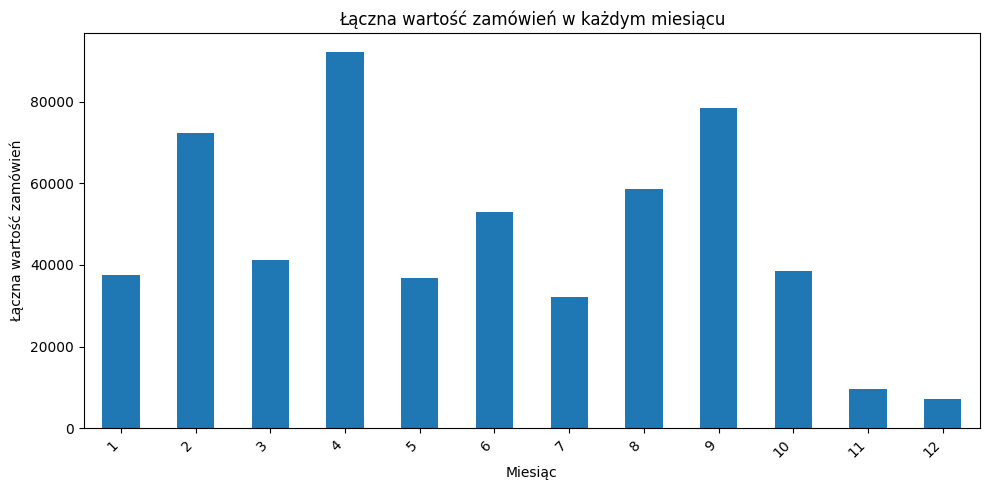

In [116]:
#Wykres słupkowy łącznej wartości zamówień w każdym miesiącu.
import matplotlib.pyplot as plt
miesiecznie = (
    df.groupby(df["miesiac"])["wartosc_zamowienia"]
      .sum()
      .sort_index()
)

ax = miesiecznie.plot(kind="bar", figsize=(10, 5), title="Łączna wartość zamówień w każdym miesiącu")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Łączna wartość zamówień")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Część 6 — Zapis

In [117]:
#Zapisz oczyszczony DataFrame do pliku zamowienia_clean.csv.
df.to_csv("zamowienia_clean.csv", index=False)
print(f"Wygenerowano plik 'zamowienia_clean.csv' — {len(df)} wierszy")

Wygenerowano plik 'zamowienia_clean.csv' — 339 wierszy
